In [1]:
import os
import sys
import time
os.environ['TF_ENABLE_ONEDNN_OPTS'] = str(0)

import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
from tensorflow import keras  # tf.keras
import matplotlib as mpl
import matplotlib.pyplot as plt

2023-06-18 03:41:16.704458: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-18 03:41:16.883735: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-06-18 03:41:17.734205: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-06-18 03:41:17.734292: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object fi

In [2]:
print("python", sys.version)
for module in mpl, np, pd, sklearn, tf, keras:
    print(module.__name__, module.__version__)

python 3.7.12 | packaged by conda-forge | (default, Oct 26 2021, 06:08:21) 
[GCC 9.4.0]
matplotlib 3.5.3
numpy 1.21.6
pandas 1.3.5
sklearn 1.0.2
tensorflow 2.10.1
keras.api._v2.keras 2.10.0


In [3]:
assert sys.version_info >= (3, 5) # Python ≥3.5 required
assert tf.__version__ >= "2.0"    # TensorFlow ≥2.0 required

In [4]:
from test_utility import *

In [5]:
from test_utility import *
# from test_trans import *

In [6]:
import ipyparams
notebookName = ipyparams.notebook_name  # This only works on browser.
data_model = notebookName

dir_data = "/mnt/data/Trading/"

#============================================================= Dataset

Nx = 250 # ------------- test
Ny = 11
Ns = 5 #--------------------- test
BatchSize = 64

Shift = 3 # past 2

CandleFile = "18-01-01-00-00-23-05-20-20-23-5m"
SmallSigma = 1
LargeSigma = 30
eFreeNoLog = True

shuffle_batch = 50  # Keep it small to speed up model loading.

dir_candles = os.path.join(dir_data, "Candles")

min_true_candle_percent_x = 80
chosen_markets_x = []
chosen_fields_names_x = ['ClosePrice'] #, 'BaseVolume']
min_true_candle_percent_y = 80
assert min_true_candle_percent_x == min_true_candle_percent_y
chosen_markets_y = []
chosen_fields_names_y = ['ClosePrice']

target_market_names = None
target_market_names = ['ETHUSDT']
tarket_market_top_percent = 15

Standardization = True
Kill_Irregulars = True  # ----------------- pls implement it
Time_into_X = True
Time_into_Y = False #
eFreeNoPlot = True

#================================================================ Model

Num_Layers = 8 # Wow
Num_Heads = 1   # As we have a single GPU, and we want to a exhaustic attention.
Factor_FF = 4
repComplexity = 8  # Wower
Dropout_Rate = 0.1

dir_Checkpoint = os.path.join(dir_data, "Checkpoints") 
checkpoint_filepath = os.path.join(dir_Checkpoint, data_model)
dir_CSVLogs = os.path.join(dir_data, "CSVLogs")
csvLogger_filepath = os.path.join(dir_CSVLogs, data_model)

#================================================================ Train

Epochs_Initial = 5000
HuberThreshold = 1.0
Checkpoint_Monitor = "val_loss"
EarlyStopping_Min_Monitor = "val_loss"
EarlyStopping_Patience = 30

Optimizer = "adam"
Learning_Rate = 0.0001  # default: 0.001

#=============================================================== Checksum

assert int(data_model.split('.')[1]) == int(CandleFile.split('-')[-1][:-1])
assert int(data_model.split('.')[2]) == Nx
assert int(data_model.split('.')[3]) == Ny
assert int(data_model.split('.')[4]) == min_true_candle_percent_x
assert int(data_model.split('.')[6]) == Num_Layers
targets = data_model.split('.')[5]
if targets.isnumeric():
    assert target_market_names is None
    assert int(targets) == tarket_market_top_percent
else:
    for target in targets.split(','):
        assert (target+'usdt').upper() in target_market_names

In [7]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    print(gpus)
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            # tf.config.experimental.set_virtual_device_configuration(
            #     gpu,[tf.config.experimental.VirtualDeviceConfiguration(memory_limit=5120)]) # why 5120?
            # logical_gpus = tf.config.experimental.list_logical_devices('GPU')
            # print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)

mirrored_strategy = None
if len(gpus) > 1: 
    mirrored_strategy = tf.distribute.MirroredStrategy()
    Learning_Rate = Learning_Rate * len(gpus) * 3 / 4

# tf.config.experimental.set_virtual_device_configuration(
#     gpus[0],[tf.config.experimental.VirtualDeviceConfiguration(memory_limit=5120)])

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
from datetime import datetime, timedelta
import sys 
sys.path.append('..')
import json

In [9]:
def upgrade_file(path):
    with open(path, "+tw") as f:
        f.write("# Sorry, the content is removed.")
        f.write("\n# Please ask Mike for the content.")

In [10]:
folders = [dir_data, dir_candles, dir_Checkpoint, dir_CSVLogs]
for folder in folders:
    if not os.path.isdir(folder):
        os.mkdir(folder)

In [11]:
#==================== Load candle data into 'table' with shape of (time, markets, 10 fields) ====================
Candles = np.load( os.path.join( dir_candles, "table-" + CandleFile + ".npy") )
Candles = np.swapaxes(Candles, 0, 1)
Candles = Candles.astype(np.float32)    # Ugly, just confirm.
print("Candles: {}".format(Candles.shape))

Candles: (565633, 336, 10)


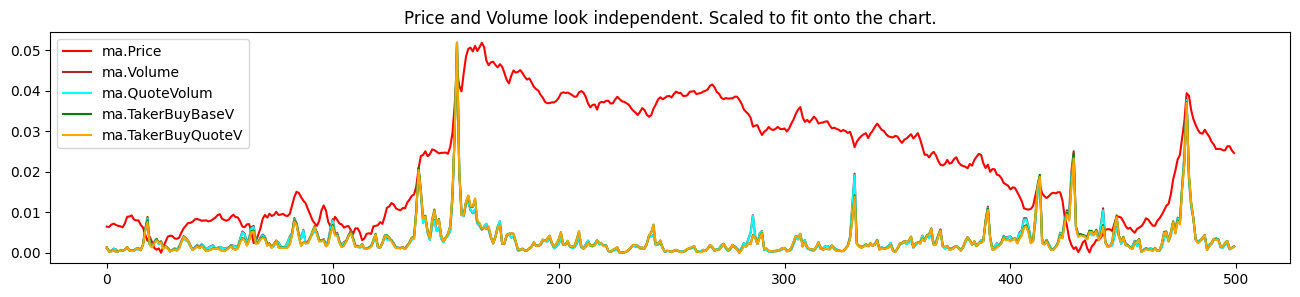

In [12]:
market = 5
Show_Price_Volume_10(Candles[:, market, :], 1, 1, 500)

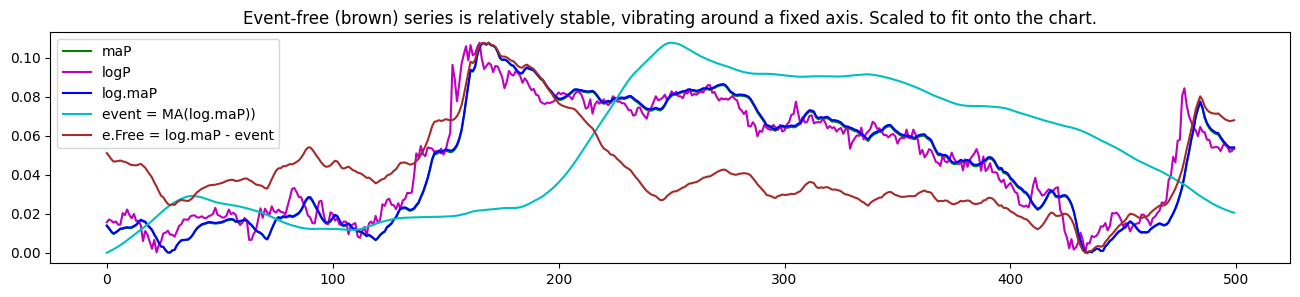

In [13]:
Event_Free_Learning_Scheme_10(Candles[:, market, :], 3, 30, 500)

In [14]:
#==================== Delete 7 candle fields from 'Candles'. ====================
# Candles.shape becomes (time, markets, ['ClosePrice', 'BaseVolume', 'BuyerBaseVolume'] )

CandleMarks = Candles[:, :, 9] # keep it for later use
Candles = np.delete(Candles, [0, 1, 2, 5, 6, 8, 9], axis = 2) # delete Open, High, Low, qVolume, #Trades, bQVolume, CandleMarks
all_field_names = ['ClosePrice', 'BaseVolume', 'BuyerBaseVolume']

assert (~np.isfinite(Candles)).any() == False

table_markets = []
with open( os.path.join( dir_candles, "reports-" + CandleFile + ".json"), "r") as f:
    reports = json.loads(f.read())
print(reports[:2])

all_market_names = [ s[0: s.find(':')] for s in reports if 'Success' in s ]
assert Candles.shape[1] == len(all_market_names)
print(Candles.shape, len(all_market_names), all_market_names[:2])

['ALICEUSDT: 565633, 336924 created. Success. 1-th.', 'DOTUSDT: 565633, 277039 created. Success. 2-th.']
(565633, 336, 3) 336 ['ALICEUSDT', 'DOTUSDT']


In [15]:
Candles, CandleMarks, all_market_names, x_indices, y_indices, \
chosen_market_names_x, chosen_field_names_x, chosen_market_names_y, chosen_field_names_y, \
chosen_market_names, chosen_field_names, \
target_markets_names, target_markets = \
get_formed_data( Candles, CandleMarks, all_market_names, all_field_names, 
        min_true_candle_percent_x, chosen_fields_names_x, min_true_candle_percent_y, chosen_fields_names_y,
        target_market_names, tarket_market_top_percent
)

print(Candles.shape)
print(CandleMarks.shape)
print(len(all_market_names))
print(x_indices)
print(y_indices)
print(chosen_market_names_x)
print(chosen_field_names_x)
print(chosen_market_names_y)
print(chosen_field_names_y)
print(chosen_market_names)
print(chosen_field_names)
print(target_markets_names)
print(target_markets)
print(len(chosen_market_names_x), len(chosen_market_names_y), len(target_markets_names))

(565633, 19, 1)
(565633, 19)
336
((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18), (0,))
((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18), (0,))
['NEOUSDT', 'LTCUSDT', 'BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'QTUMUSDT', 'ADAUSDT', 'XRPUSDT', 'EOSUSDT', 'XLMUSDT', 'IOTAUSDT', 'ONTUSDT', 'TRXUSDT', 'ETCUSDT', 'ICXUSDT', 'NULSUSDT', 'VETUSDT', 'LINKUSDT', 'WAVESUSDT']
['ClosePrice']
['NEOUSDT', 'LTCUSDT', 'BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'QTUMUSDT', 'ADAUSDT', 'XRPUSDT', 'EOSUSDT', 'XLMUSDT', 'IOTAUSDT', 'ONTUSDT', 'TRXUSDT', 'ETCUSDT', 'ICXUSDT', 'NULSUSDT', 'VETUSDT', 'LINKUSDT', 'WAVESUSDT']
['ClosePrice']
['NEOUSDT', 'LTCUSDT', 'BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'QTUMUSDT', 'ADAUSDT', 'XRPUSDT', 'EOSUSDT', 'XLMUSDT', 'IOTAUSDT', 'ONTUSDT', 'TRXUSDT', 'ETCUSDT', 'ICXUSDT', 'NULSUSDT', 'VETUSDT', 'LINKUSDT', 'WAVESUSDT']
['ClosePrice']
['ETHUSDT']
(3,)
19 19 1


In [16]:
start_ts, interval_s, timestamps_abs = get_timestamps_2(CandleFile, Candles.shape[0])
print(start_ts, interval_s, timestamps_abs.shape, timestamps_abs[:3])

Times = get_time_features(timestamps_abs)
Times = Times.astype(Candles.dtype)
size_time = Times.shape[1]

assert Candles.shape[0] == Times.shape[0]
print(Candles.shape, Times.shape)

1514764800 300 (565633,) [1514764800 1514765100 1514765400]
(565633, 19, 1) (565633, 4)


In [17]:
#==================== Generate event-free data into Data ====================
# Data loses heading items.
# Do it before: Permute Data in time

alpha = 3; beta = 3 # beta is used in 'get_eFree_with_plot'. Ugly coupling.
event_free_data_loss = 3 * ( alpha * SmallSigma + LargeSigma)
eFree = np.zeros( (Candles.shape[0] - event_free_data_loss, len(chosen_market_names), len(chosen_field_names)), dtype = Candles.dtype )

for market in range(Candles.shape[1]):
    for field in range(Candles.shape[2]):
        sSigma = SmallSigma
        if all_field_names[field] == 'BaseVolume': sSigma = SmallSigma * alpha
        P, maP, logP, log_maP, event, eventFree = \
        get_eFree_with_plot(all_market_names[market], all_field_names[field], Candles[:, market, field], sSigma,
                            LargeSigma, Candles.shape[0] - event_free_data_loss, noPlot=eFreeNoPlot, noLog=eFreeNoLog)
        assert Candles.shape[0] - event_free_data_loss == eventFree.shape[0]
        eventFree = eventFree.astype(Candles.dtype)
        Candles[event_free_data_loss:, market, field] = eventFree

Candles = Candles[event_free_data_loss + Shift:]
Times = Times[event_free_data_loss + Shift:]
assert Candles.shape[0] == Times.shape[0]

print(Candles.shape, Times.shape)

(565531, 19, 1) (565531, 4)


In [18]:
Standard = None

if Standardization:
    Candles, Standard = standardize_2(Candles)

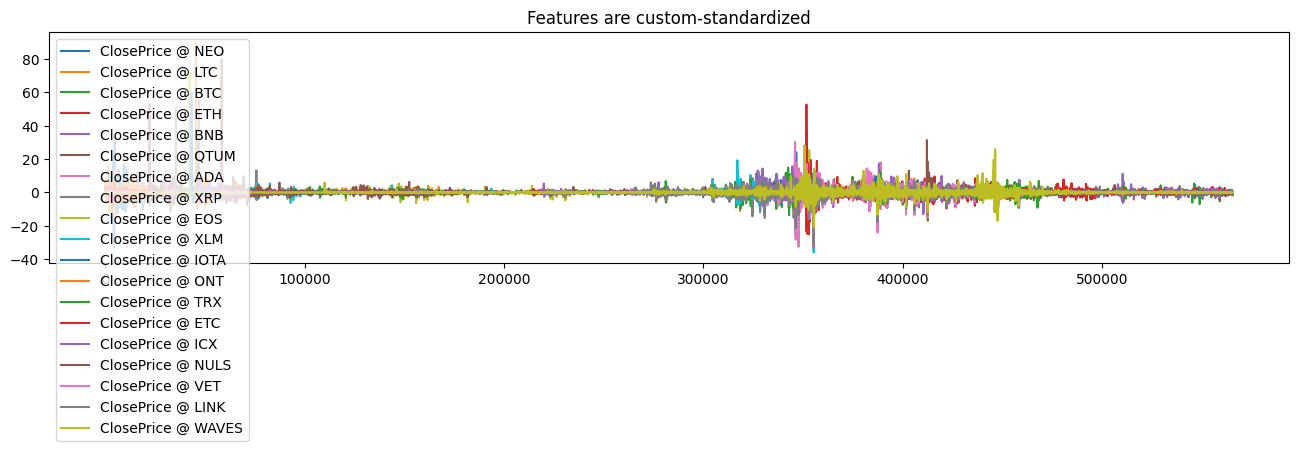

In [19]:
fig = plt.figure(figsize=(16,3))
ax = fig.add_subplot(111)
ax.set_title("Features are custom-standardized" if Standardization else "Features are not standardized")
for market in range(Candles.shape[1]):
    for field in range(Candles.shape[2]):
        ax.plot(Candles[:, market, field], label = "{} @ {}".format(all_field_names[field], all_market_names[market][:-len('USDT')]))
ax.legend(loc = 'upper left')
plt.show()

In [20]:
sample_anchores_t, sample_anchores_v = get_sample_anchors_2(Candles, Nx, Ny, Ns)
print(sample_anchores_t.shape, sample_anchores_v.shape)

(79138,) (33917,)


In [21]:
ds_train, ds_valid, dx, dy = \
get_datasets_2(
    Candles, Time_into_X, Time_into_Y, Times, 
    sample_anchores_t, sample_anchores_v,
    Nx, x_indices, Ny, y_indices, size_time, target_markets,
    BatchSize, shuffle_batch, shuffle=(len(gpus)<=1)
)

2023-06-18 03:41:32.879833: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-06-18 03:41:33.879748: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 36013 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:00:04.0, compute capability: 8.0


In [22]:
train = ds_train.take(1)
print(train)

<TakeDataset element_spec=((TensorSpec(shape=<unknown>, dtype=tf.float32, name=None), TensorSpec(shape=<unknown>, dtype=tf.float32, name=None)), TensorSpec(shape=<unknown>, dtype=tf.float32, name=None))>


In [23]:
model = None

if mirrored_strategy is None:
    model = build_model_2(
        dx, dy, Num_Layers, Num_Heads, Factor_FF, repComplexity, Dropout_Rate,
        HuberThreshold, Optimizer, Learning_Rate
    )
else:
    with mirrored_strategy.scope():
        model = build_model_2(
            dx, dy, Num_Layers, Num_Heads, Factor_FF, repComplexity, Dropout_Rate,
            HuberThreshold, Optimizer, Learning_Rate
        )

In [24]:
callbacks = get_callbacks(
    checkpoint_filepath, Checkpoint_Monitor, 
    csvLogger_filepath, 
    EarlyStopping_Min_Monitor, EarlyStopping_Patience
)

try:
    model.load_weights(checkpoint_filepath)
    print("Loading a checkpoint...")
except:
    print("No checkpoint found.")
    pass

try:
    columns = ('loss', 'val_loss', 'mTA', 'val_mTA')
    plot_csv_train_history(csvLogger_filepath, columns, title=data_model)
except:
    pass

No checkpoint found.


In [25]:
model.fit(
    ds_train, # x and y_true
    validation_data=ds_valid,
    epochs=1, #Epochs_Initial,
    callbacks=callbacks
)

2023-06-18 03:42:07.685171: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.



   1/1237 [..............................] - ETA: 9:37:42 - loss: 0.5951 - mTA: 0.4797

2023-06-18 03:42:08.369859: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8200


1237/1237 [==============================] - 181s 124ms/step - loss: 0.0954 - mTA: 0.5085 - val_loss: 0.0395 - val_mTA: 0.5994


In [26]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 candle_input_x (InputLayer)    [(None, None, 24)]   0           []                               
                                                                                                  
 candle_input_y (InputLayer)    [(None, None, 24)]   0           []                               
                                                                                                  
 trans (ConTransformer)         (None, None, 24)     212184      ['candle_input_x[0][0]',         
                                                                  'candle_input_y[0][0]']         
                                                                                                  
Total params: 212,184
Trainable params: 212,184
Non-trainable params: 0
______________________

In [27]:
model.fit(
    ds_train, # x and y_true
    validation_data=ds_valid,
    epochs=20, #Epochs_Initial,
    callbacks=callbacks
)

Epoch 1/20
1237/1237 [==============================] - 179s 145ms/step - loss: 0.0547 - mTA: 0.5161 - val_loss: 0.0359 - val_mTA: 0.6179
Epoch 2/20
1237/1237 [==============================] - 177s 143ms/step - loss: 0.0472 - mTA: 0.5206 - val_loss: 0.0330 - val_mTA: 0.6206
Epoch 3/20
1237/1237 [==============================] - 171s 139ms/step - loss: 0.0435 - mTA: 0.5233 - val_loss: 0.0325 - val_mTA: 0.6237
Epoch 4/20
1237/1237 [==============================] - 176s 142ms/step - loss: 0.0417 - mTA: 0.5269 - val_loss: 0.0326 - val_mTA: 0.6221
Epoch 5/20
1237/1237 [==============================] - 174s 141ms/step - loss: 0.0402 - mTA: 0.5277 - val_loss: 0.0311 - val_mTA: 0.6228
Epoch 6/20
1237/1237 [==============================] - 173s 140ms/step - loss: 0.0386 - mTA: 0.5289 - val_loss: 0.0342 - val_mTA: 0.6261
Epoch 7/20
1237/1237 [==============================] - 174s 141ms/step - loss: 0.0342 - mTA: 0.5301 - val_loss: 0.0297 - val_mTA: 0.6256
Epoch 8/20
1237/1237 [============

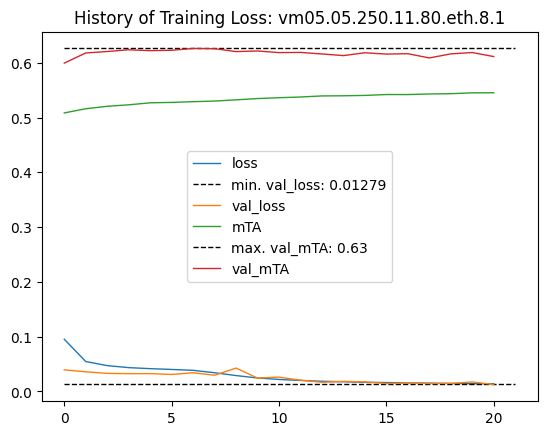

In [28]:
columns = ('loss', 'val_loss', 'mTA', 'val_mTA')
plot_csv_train_history(csvLogger_filepath, columns, title=data_model)

In [29]:
model.fit(
    ds_train, # x and y_true
    validation_data=ds_valid,
    epochs=50, #Epochs_Initial,
    callbacks=callbacks
)

Epoch 1/50
1237/1237 [==============================] - 167s 135ms/step - loss: 0.0137 - mTA: 0.5449 - val_loss: 0.0127 - val_mTA: 0.6132
Epoch 2/50
1237/1237 [==============================] - 171s 138ms/step - loss: 0.0134 - mTA: 0.5470 - val_loss: 0.0157 - val_mTA: 0.6201
Epoch 3/50
1237/1237 [==============================] - 169s 137ms/step - loss: 0.0132 - mTA: 0.5467 - val_loss: 0.0121 - val_mTA: 0.6114
Epoch 4/50
1237/1237 [==============================] - 166s 134ms/step - loss: 0.0130 - mTA: 0.5482 - val_loss: 0.0130 - val_mTA: 0.6193
Epoch 5/50
1237/1237 [==============================] - 170s 138ms/step - loss: 0.0125 - mTA: 0.5473 - val_loss: 0.0122 - val_mTA: 0.6181
Epoch 6/50
1237/1237 [==============================] - 167s 135ms/step - loss: 0.0126 - mTA: 0.5484 - val_loss: 0.0169 - val_mTA: 0.6232
Epoch 7/50
1237/1237 [==============================] - 165s 134ms/step - loss: 0.0123 - mTA: 0.5489 - val_loss: 0.0129 - val_mTA: 0.6175
Epoch 8/50
1237/1237 [============

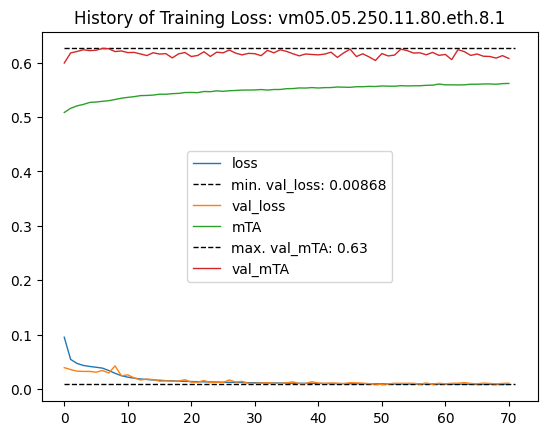

In [30]:
columns = ('loss', 'val_loss', 'mTA', 'val_mTA')
plot_csv_train_history(csvLogger_filepath, columns, title=data_model)

In [ ]:
model.fit(
    ds_train, # x and y_true
    validation_data=ds_valid,
    epochs=500, #Epochs_Initial,
    callbacks=callbacks
)

Epoch 1/500
1237/1237 [==============================] - 168s 136ms/step - loss: 0.0084 - mTA: 0.5613 - val_loss: 0.0097 - val_mTA: 0.6132
Epoch 2/500
1237/1237 [==============================] - 172s 139ms/step - loss: 0.0084 - mTA: 0.5620 - val_loss: 0.0099 - val_mTA: 0.6116
Epoch 3/500
1237/1237 [==============================] - 170s 137ms/step - loss: 0.0086 - mTA: 0.5617 - val_loss: 0.0113 - val_mTA: 0.6114
Epoch 4/500
1237/1237 [==============================] - 169s 136ms/step - loss: 0.0084 - mTA: 0.5618 - val_loss: 0.0092 - val_mTA: 0.6142
Epoch 5/500
1237/1237 [==============================] - 170s 138ms/step - loss: 0.0086 - mTA: 0.5629 - val_loss: 0.0106 - val_mTA: 0.6162
Epoch 6/500
1237/1237 [==============================] - 172s 139ms/step - loss: 0.0084 - mTA: 0.5625 - val_loss: 0.0104 - val_mTA: 0.6170
Epoch 7/500
1237/1237 [==============================] - 168s 136ms/step - loss: 0.0084 - mTA: 0.5626 - val_loss: 0.0115 - val_mTA: 0.6162
Epoch 8/500
1237/1237 [====

In [ ]:
columns = ('loss', 'val_loss', 'mTA', 'val_mTA')
plot_csv_train_history(csvLogger_filepath, columns, title=data_model)

In [ ]:
model.fit(
    ds_train, # x and y_true
    validation_data=ds_valid,
    epochs=500, #Epochs_Initial,
    callbacks=callbacks
)

In [ ]:
columns = ('loss', 'val_loss', 'mTA', 'val_mTA')
plot_csv_train_history(csvLogger_filepath, columns, title=data_model)

In [ ]:
model.fit(
    ds_train, # x and y_true
    validation_data=ds_valid,
    epochs=500, #Epochs_Initial,
    callbacks=callbacks
)

In [ ]:
columns = ('loss', 'val_loss', 'mTA', 'val_mTA')
plot_csv_train_history(csvLogger_filepath, columns, title=data_model)